In [ ]:
from tensorflow import keras
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from datetime import datetime
import os

In [ ]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [ ]:
 data1 = pd.read_csv('MicrosoftStock.csv')

In [ ]:
data1.head()

,index,date,open,high,low,close,volume,Name
0,390198,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
1,390199,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2,390200,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
3,390201,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
4,390202,2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


In [ ]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   1259 non-null   int64  
 1   date    1259 non-null   object 
 2   open    1259 non-null   float64
 3   high    1259 non-null   float64
 4   low     1259 non-null   float64
 5   close   1259 non-null   float64
 6   volume  1259 non-null   int64  
 7   Name    1259 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 78.8+ KB


In [ ]:
data1.isnull().sum()

,0
index,0
date,0
open,0
high,0
low,0
close,0
volume,0
Name,0


In [ ]:
data.describe()

,index,open,high,low,close,volume
count,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000,1.259000e+03
mean,390827.000000,51.026394,51.436007,50.630397,51.063081,3.386946e+07
std,363.586303,14.859387,14.930144,14.774630,14.852117,1.958979e+07
min,390198.000000,27.350000,27.600000,27.230000,27.370000,7.425603e+06
25%,390512.500000,40.305000,40.637500,39.870000,40.310000,2.254879e+07
50%,390827.000000,47.440000,47.810000,47.005000,47.520000,2.938758e+07
75%,391141.500000,59.955000,60.435000,59.275000,59.730000,3.842024e+07
max,391456.000000,95.140000,96.070000,93.720000,95.010000,2.483542e+08


In [ ]:
data1.value_counts()

,,,,,,,,count
index,date,open,high,low,close,volume,Name,
391456,2018-02-07,90.49,91.77,89.20,89.61,41107592,MSFT,1
390198,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT,1
390199,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT,1
390200,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT,1
390201,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT,1
...,...,...,...,...,...,...,...,...
390213,2013-03-04,27.85,28.15,27.70,28.15,38163549,MSFT,1
390212,2013-03-01,27.72,27.98,27.52,27.95,34849287,MSFT,1
390211,2013-02-28,27.88,27.97,27.74,27.80,35836861,MSFT,1


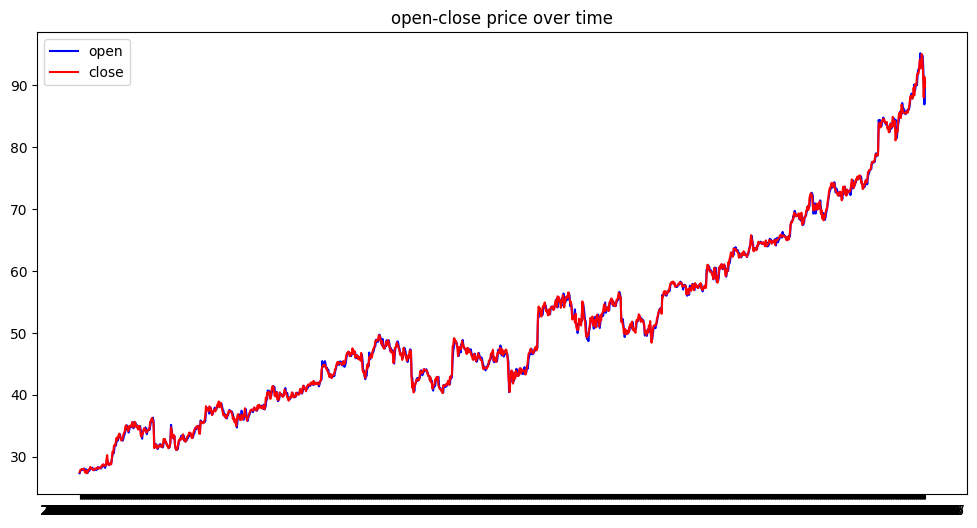

In [ ]:
# initial data visualization
# open and close price of time
plt.figure(figsize=(12,6))
plt.plot(data1['date'],data1['open'],label='open',color='blue')
plt.plot(data1['date'],data1['close'],label='close',color='red')
plt.title('open-close price over time')
plt.legend()
plt.show()

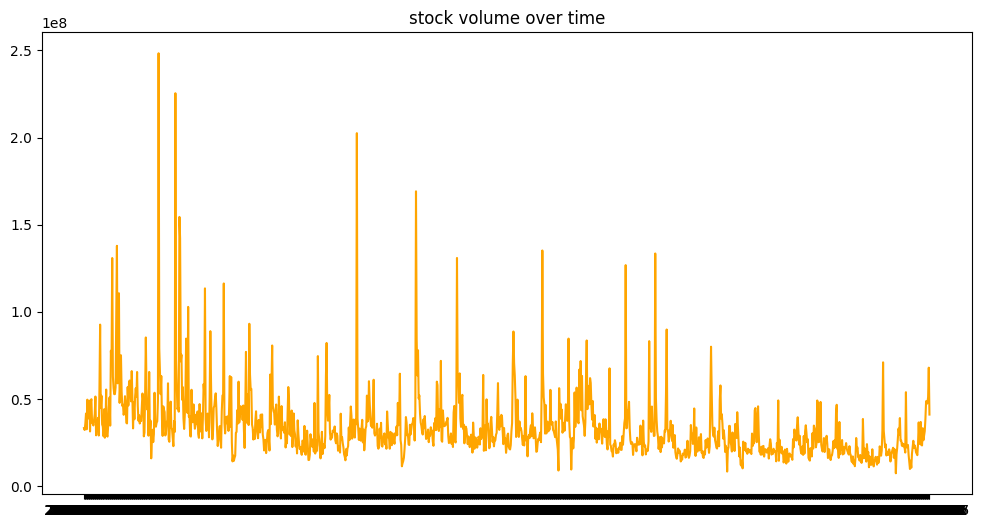

In [ ]:
# Trading volumn check for outliers

plt.figure(figsize=(12,6))
plt.plot(data1['date'],data1['volume'],label='volume',color='orange')
plt.title('stock volume over time')
plt.show()

In [ ]:
# drop non NUmeric data

numeric_data = data1.select_dtypes(include=['int64','float64'])

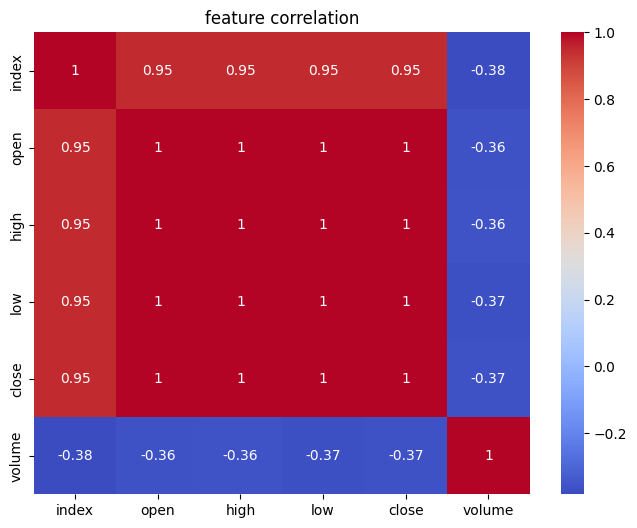

In [ ]:
# check for correlations between features

plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(),annot=True,cmap='coolwarm')
plt.title('feature correlation')
plt.show()

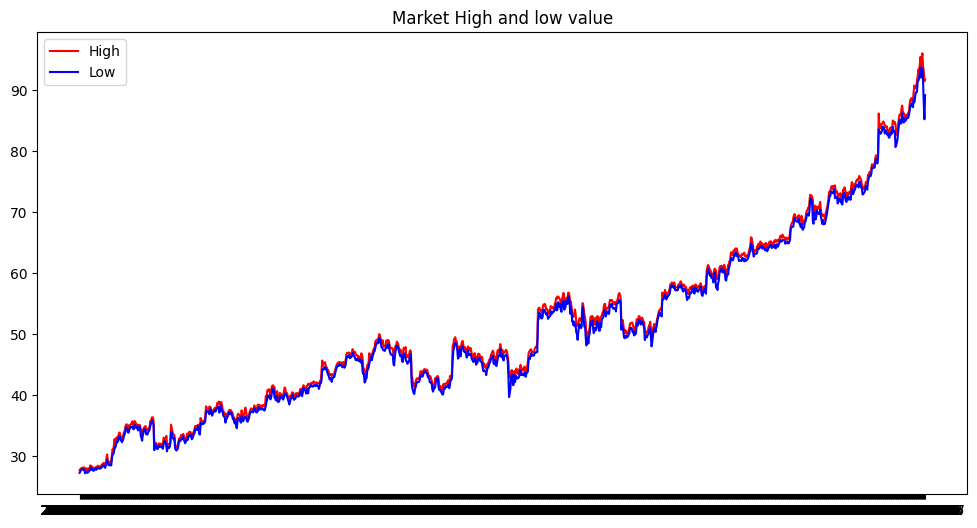

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(data1['date'],data1['high'],label='High',color='red')
plt.plot(data1['date'],data1['low'],label='Low',color='blue')
plt.title('Market High and low value')
plt.legend()
plt.show()

In [ ]:
print(f"hight value :{max(data1['high'])}")
print(f"low value :{min(data1['low'])}")

hight value :96.07
low value :27.23


In [ ]:
#convert the date info Date time creat a date filter

data1['date'] = pd.to_datetime(data1['date'])

In [ ]:
prediction = data1.loc[
    (data1['date'] > datetime(2013,1,1))&
    (data1['date'] < datetime(2018,1,1))
]

Text(0.5, 1.0, 'price over time')

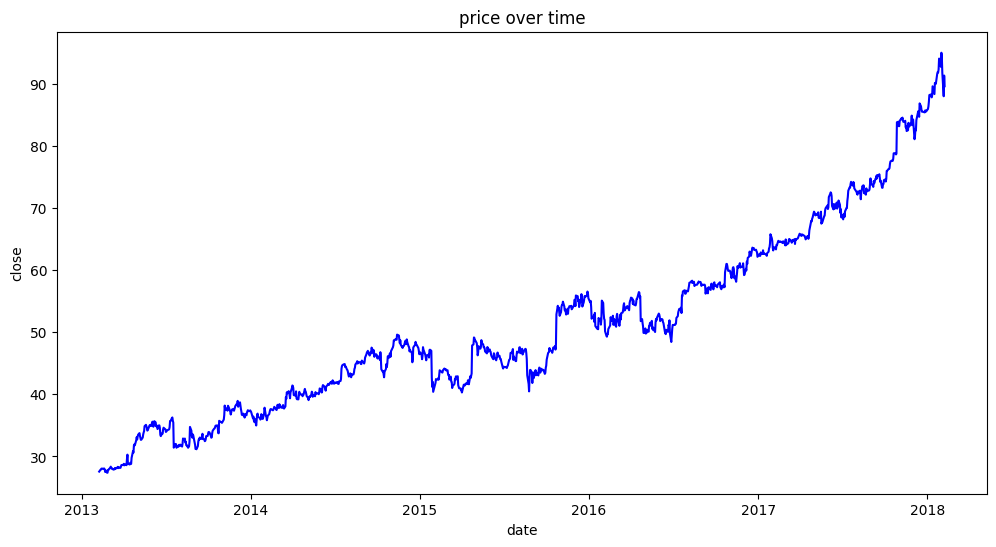

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(data1['date'],data1['close'],color='blue')
plt.xlabel('date')
plt.ylabel('close')
plt.title('price over time')

In [ ]:
# prepare for the LSTM model

stock_close = data1['close']

dataset = stock_close.values
dataset = dataset.reshape(-1,1)
training_data_len = int(np.ceil(len(dataset) * 0.95))

In [ ]:
# preprocessing data

scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

In [ ]:
training_data = scaled_data[:training_data_len]

x_train, y_train = [], []

In [ ]:
#create a sliding window for our stcok (60 dayes)

for i in range(60,len(training_data)):
  x_train.append(training_data[i-60:i,0])
  y_train.append(training_data[i,0])

In [ ]:
x_train , y_train = np.array(x_train),np.array(y_train)

In [ ]:
x_train = np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))

In [ ]:
#build the model

model = keras.models.Sequential()

model.add(keras.layers.LSTM(64,return_sequences=True, input_shape=(x_train.shape[1],1)))

model.add(keras.layers.LSTM(64,return_sequences=False))

model.add(keras.layers.Dense(128,activation='relu'))

model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(1,activation='linear'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer= 'adam',loss='mae',metrics=[keras.metrics.RootMeanSquaredError()])

In [ ]:
training = model.fit(x_train,y_train, epochs=20,batch_size=32)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - loss: 0.3882 - root_mean_squared_error: 0.5216
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.1438 - root_mean_squared_error: 0.1972
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.1252 - root_mean_squared_error: 0.1658
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.1319 - root_mean_squared_error: 0.1832
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.1161 - root_mean_squared_error: 0.1653
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.1132 - root_mean_squared_error: 0.1533
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.1060 - root_mean_squared_error: 0.1472
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.1087 - root_mean_squared_error: 0.1490
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.1065 - root_mean_squared_error: 0.1510
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.1064 - root_mean_squared_error: 0.1449

In [ ]:
test_data = scaled_data[training_data_len - 60:]

x_test , y_test = [],dataset[training_data_len:]

In [ ]:
for i in range(60,len(test_data)):
  x_test.append(test_data[i-60:i,0])


x_test = np.array(x_test)
x_test = np.reshape(x_test,(x_test.shape[0],x_test.shape[1],1))

In [ ]:
prediction = model.predict(x_test)
prediction = scaler.inverse_transform(prediction)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 857ms/step


In [ ]:
train = data1[:training_data_len]
test = data1[training_data_len:]

In [ ]:
test = test.copy()
test['prediction'] = prediction

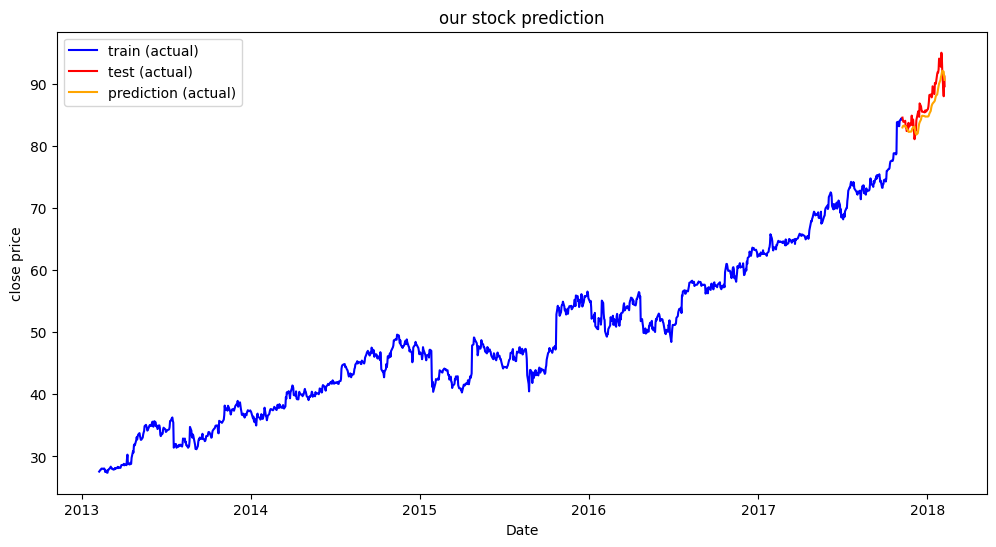

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train['date'],train['close'],label='train (actual)',color='blue')
plt.plot(test['date'],test['close'],label='test (actual)',color='red')
plt.plot(test['date'],test['prediction'],label='prediction (actual)',color='orange')
plt.title('our stock prediction')
plt.xlabel('Date')
plt.ylabel('close price')
plt.legend()
plt.show()